# Capitolo 6 — Una RNN a mano, con la backpropagation nel tempo (§ 6.2)
Su una curva sintetica: forward, BPTT, e la misura di quanto gradiente arriva k passi indietro.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import dati
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
fissa_seme(42)

t = np.arange(0, 400) * 0.1; serie = np.sin(t) + 0.3 * np.sin(3.1 * t)
L, H = 20, 16
def finestre(s):
    X = np.stack([s[i:i + L] for i in range(len(s) - L)]); return X, s[L:]
X_tr, y_tr = finestre(serie[:300]); X_te, y_te = finestre(serie[300:])
Wx = np.random.randn(1, H) * 0.3; Wh = np.random.randn(H, H) * 0.3; b = np.zeros(H); Wo = np.random.randn(H) * 0.3; bo = 0.0

In [2]:
def forward(x):                      # x: L valori
    hs = [np.zeros(H)]
    for k in range(L): hs.append(np.tanh(x[k] * Wx[0] + hs[-1] @ Wh + b))
    return hs, hs[-1] @ Wo + bo

storia = []
for epoca in range(60):
    tot = 0; dWx = np.zeros_like(Wx); dWh = np.zeros_like(Wh); db = np.zeros(H); dWo = np.zeros(H); dbo = 0.0
    for x, y in zip(X_tr, y_tr):
        hs, y_hat = forward(x); e = y_hat - y; tot += e ** 2
        dWo += e * hs[-1]; dbo += e
        dh = e * Wo                                       # gradiente sullo stato finale
        for k in range(L - 1, -1, -1):                    # BPTT
            dz = dh * (1 - hs[k + 1] ** 2)
            dWx += np.outer([x[k]], dz); dWh += np.outer(hs[k], dz); db += dz
            dh = dz @ Wh.T
    n = len(X_tr); lr = 0.02
    Wx -= lr * dWx / n; Wh -= lr * dWh / n; b -= lr * db / n; Wo -= lr * dWo / n; bo -= lr * dbo / n
    storia.append(tot / n)
pred = np.array([forward(x)[1] for x in X_te])
print(f"MSE finale {storia[-1]:.4f} | MAE test {np.mean(np.abs(pred - y_te)):.3f} | persistenza {np.mean(np.abs(X_te[:, -1] - y_te)):.3f}")

MSE finale 0.0120 | MAE test 0.082 | persistenza 0.088


## Quanto gradiente arriva k passi indietro, per tre scale di W_stato

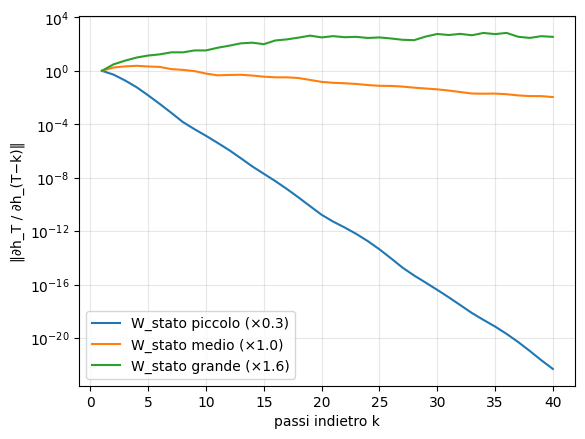

In [3]:
np.random.seed(0)
for scala, lab in ((0.3, "W_stato piccolo (×0.3)"), (1.0, "W_stato medio (×1.0)"), (1.6, "W_stato grande (×1.6)")):
    W = np.random.randn(H, H) * scala * 0.25; h = np.zeros(H); J = np.eye(H); norme = []
    x = np.sin(np.arange(40) * 0.3)
    for k in range(40):
        h = np.tanh(x[k] * 0.5 + h @ W); D = np.diag(1 - h ** 2); J = J @ (W @ D) if k > 0 else np.eye(H)
        norme.append(np.linalg.norm(J, 2))
    plt.semilogy(range(1, 41), norme, label=lab)
plt.xlabel("passi indietro k"); plt.ylabel("‖∂h_T / ∂h_(T−k)‖"); plt.legend(); plt.grid(alpha=0.3, which="both"); plt.show()

## Lo stesso problema con `nn.LSTM`

In [4]:
class LSTMPrevisione(nn.Module):
    def __init__(self, nascosti=16):
        super().__init__(); self.lstm = nn.LSTM(1, nascosti, batch_first=True); self.fc = nn.Linear(nascosti, 1)
    def forward(self, x): out, _ = self.lstm(x); return self.fc(out[:, -1, :]).squeeze(1)
fissa_seme(42); m = LSTMPrevisione(); opt = torch.optim.Adam(m.parameters(), lr=1e-2); fn = nn.MSELoss()
Xt, yt = torch.from_numpy(X_tr).float().unsqueeze(-1), torch.from_numpy(y_tr).float()
for epoca in range(200):
    opt.zero_grad(); fn(m(Xt), yt).backward(); opt.step()
with torch.no_grad(): p = m(torch.from_numpy(X_te).float().unsqueeze(-1)).numpy()
print(f"LSTM: MAE test {np.mean(np.abs(p - y_te)):.3f}")

LSTM: MAE test 0.013
